# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 28     |  |
| :-------------|:-------------|
| Casper Jansen| 6265200 |
| Jan van de Poll| 6527590 |
| Wouter Zeilmaker| 6585043 |

| Planning Groep: 28     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12:00 |
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14:30 |
| Pauze 1| 12:45 |
| Pauze 2| 15:00 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](fotoschetsen27.jpeg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|lichtsensor | licht aan uit lokaal | bij licht aan moet die minimaal 50 tot 1000 lumen aangeven en bij licht uit  maximaal 0-50 lumen |
|lichtsensor | Hoever gaat licht door papierblaadjes | Hij moet tussenstappen van 10 lumen kunnen meten in een range van 10-1000 lumen |
|lichtsensor | Hoe donker kan je hem zelf maken zonder attributen | een nauwkeurigheid kleiner dan 1 lumen |
|druksensor | zou je er geluid mee kunnen meten | Een nauwkeurigheid van 0.5 newton kunnen aangeven |
|druksensor | impact van een knal | moet minstens een maximum van 3000 newton kunnen aangeven en een minimum van 20 newton |
|druksensor | gewicht van een object bepalen | moet minstens een een kracht van 0,5 newton kunnen meten en maximun ver wachten we rond de 50 N. De druksensor moet een nauwkeurigheid hebben van 100 gram. |
| temperatuursensor | lichaamstemperatuur | een nauwkeurigheid van 0.2 kelvin is vereist |
| temperatuursensor | warmteverlies | een nauwkeurigheid van 0.5 kelvin is vereist en hij moet minstens tot om de 5 seconden kunnen meten en zelf moet die niet teveel warmte vasthouden |
| temperatuursensor | hoe warm kan je hem krijgen met wrijving | hij moet bij 100 graden celsius   niet kapot gaan en een range hebben van 20-100 graden|

Groep 28 heeft gekozen voor druk sensor . 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](fotoopstellinggoed.jpeg "schets student")
Versie 1: Arduino met breadboard met daarop een weerstand van 10K Ohm en een Force Sensor op een weegschaal geplaatst. 

Versie 2: ipv de gewichten op de sensor te leggen, is gekozen om met een hanger het gewicht op de sensor te hangen. Om het gewicht te verdelen over de sensor worden stukje karton/papier gestapeld. Voor de rest hetzelfde als versie 1.

Ook is een schets toegevoegd van het circuit voor meer duidelijkheid.

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
gewicht in kilogram
2. Over welk bereik ga je deze variabelen veranderen?
tussen de 0.5 en 5.5 kilogram
3. Wat ga je allemaal meten?
verschillende gewichten
4. Hoeveel metingen ga je doen?
10 metingen (herhalen)
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen? 
ja daar gaan wij wel van uit 


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel
Dit is onze opstelling je ziet hier dat de sensor vast is getapet aan de tafel voor stabiliteit en zodat je hem schuin kan houden. op de sensor zit een kartonnen plaatje zodat het gewicht beter verdeeld word over het plaatje. de sensor zit in het circuit en dat is met de arduino gekoppeld die weer aan de computer is gekoppeld
 ![Alt](fotomeetopstelling.jpeg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [38]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit
# Zet hier jouw data in een voor jou handig formaat
mass = np.array([1.25, 1.702, 0.230, 0.735, 0.965, 0.452, 0.134, 0.041, 0.364]) #kg
bits = np.array([849, 881, 540, 767, 820, 695, 281, 182, 615]) #bits
u_bits = 10 #bits
u_mass = 0.0005 #kg
m_hanger = 0.037 #kg
g = 9.81 #m/s^2
F = (mass+m_hanger)*g #N
u_F = u_mass*g #N

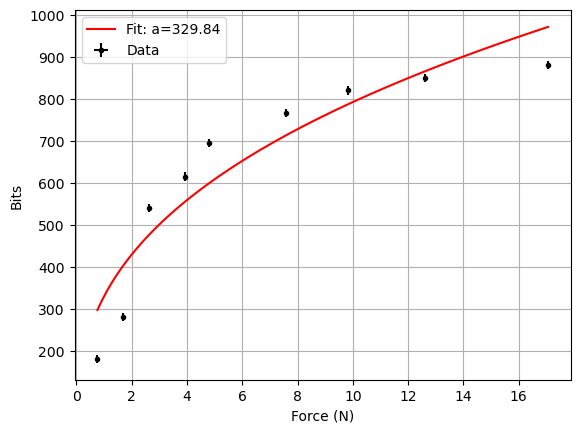

In [41]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
def function(x, a, b):
    return a*x**b

popt,pcov = curve_fit(function, F, bits)

a = popt[0]
b = popt[1]

x_fit = np.linspace(min(F), max(F), 100)

plt.figure()
plt.errorbar(F, bits, xerr=u_F, yerr=u_bits, fmt='k.', label='Data')
plt.plot(x_fit, function(x_fit, *popt), 'r-', label=f'Fit: a={a:.2f}')
plt.xlabel('Force (N)')

plt.ylabel('Bits')
plt.grid(True)
plt.legend()    

## *Opdracht 7*: Iteratie nodig?

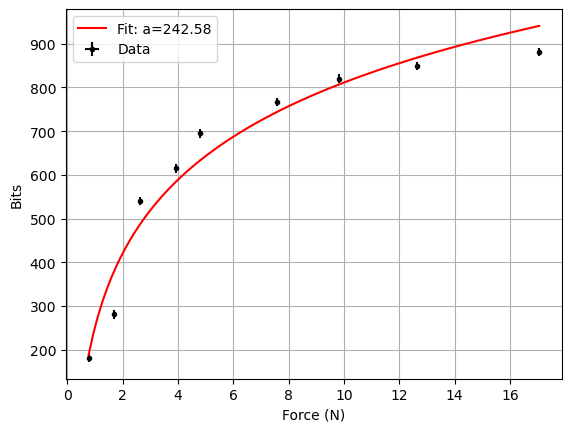

In [44]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
def function(x, a, b):
    return a*np.log(x) + b

popt,pcov = curve_fit(function, F, bits)

a = popt[0]
b = popt[1]

x_fit = np.linspace(min(F), max(F), 100)

plt.figure()
plt.errorbar(F, bits, xerr=u_F, yerr=u_bits, fmt='k.', label='Data')
plt.plot(x_fit, function(x_fit, *popt), 'r-', label=f'Fit: a={a:.2f}')
plt.xlabel('Force (N)')

plt.ylabel('Bits')
plt.grid(True)
plt.legend()   

om na te gaan of de opdacht 6 gelukt was hebben we 2 extra punten te gevoegd en kwamen we er achter dat als we een log scyale gebruikte op de x as we een lineaire lijn nodig hadden voor onze curve fit. en hebben dit daarna ook aangepast.

## *Opdracht 8*: Conclusie, leerdoel

onze cunclusie is dat deze druk sensor te veel fluctureerd om op de manier die wij hem hebben gebruikt als weegschaal te gebruiken. de metingen waren te onnauwkeurig en verscheelde te veel afhankelijk hoe en waar we ons gewicht plaatse. en daarom zeggen wij ondanks dat de curve best een beetje klopt.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel
Dit is onze opstelling je ziet hier dat de sensor vast is getapet aan de tafel voor stabiliteit en zodat je hem schuin kan houden. op de sensor zit een kartonnen plaatje zodat het gewicht beter verdeeld word over het plaatje. de sensor zit in het circuit en dat is met de arduino gekoppeld die weer aan de computer is gekoppeld
 ![Alt](fotomeetopstelling.jpeg "meetopstelling student")## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](fotoopstellinggoed.jpeg "schets student")
Versie 1: Arduino met breadboard met daarop een weerstand van 10K Ohm en een Force Sensor op een weegschaal geplaatst. 

Versie 2: ipv de gewichten op de sensor te leggen, is gekozen om met een hanger het gewicht op de sensor te hangen. Om het gewicht te verdelen over de sensor worden stukje karton/papier gestapeld. Voor de rest hetzelfde als versie 1.

Ook is een schets toegevoegd van het circuit voor meer duidelijkheid.## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
gewicht in kilogram
2. Over welk bereik ga je deze variabelen veranderen?
tussen de 0.5 en 5.5 kilogram
3. Wat ga je allemaal meten?
verschillende gewichten
4. Hoeveel metingen ga je doen?
10 metingen (herhalen)
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen? 
ja daar gaan wij wel van uit 


### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.## ## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](fotoschetsen27.jpeg "analyse: ideeen")## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|lichtsensor | licht aan uit lokaal | bij licht aan moet die minimaal 50 tot 1000 lumen aangeven en bij licht uit  maximaal 0-50 lumen |
|lichtsensor | Hoever gaat licht door papierblaadjes | Hij moet tussenstappen van 10 lumen kunnen meten in een range van 10-1000 lumen |
|lichtsensor | Hoe donker kan je hem zelf maken zonder attributen | een nauwkeurigheid kleiner dan 1 lumen |
|druksensor | zou je er geluid mee kunnen meten | Een nauwkeurigheid van 0.5 newton kunnen aangeven |
|druksensor | impact van een knal | moet minstens een maximum van 3000 newton kunnen aangeven en een minimum van 20 newton |
|druksensor | gewicht van een object bepalen | moet minstens een een kracht van 0,5 newton kunnen meten en maximun ver wachten we rond de 50 N. De druksensor moet een nauwkeurigheid hebben van 100 gram. |
| temperatuursensor | lichaamstemperatuur | een nauwkeurigheid van 0.2 kelvin is vereist |
| temperatuursensor | warmteverlies | een nauwkeurigheid van 0.5 kelvin is vereist en hij moet minstens tot om de 5 seconden kunnen meten en zelf moet die niet teveel warmte vasthouden |
| temperatuursensor | hoe warm kan je hem krijgen met wrijving | hij moet bij 100 graden celsius   niet kapot gaan en een range hebben van 20-100 graden|

Groep 28 heeft gekozen voor druk sensor . 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

we hebben deze leerdoelen voldoede voltooid

opdracht 6

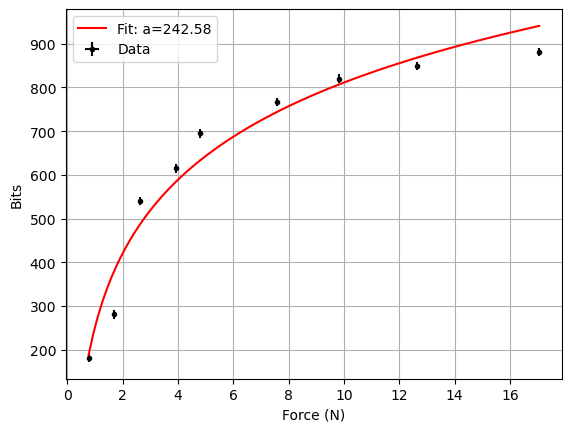

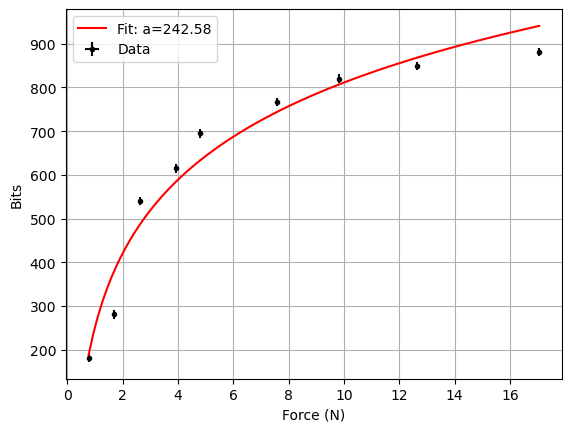

In [47]:


# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
def function(x, a, b):
    return a*np.log(x) + b

popt,pcov = curve_fit(function, F, bits)

a = popt[0]
b = popt[1]

x_fit = np.linspace(min(F), max(F), 100)

plt.figure()
plt.errorbar(F, bits, xerr=u_F, yerr=u_bits, fmt='k.', label='Data')
plt.plot(x_fit, function(x_fit, *popt), 'r-', label=f'Fit: a={a:.2f}')
plt.xlabel('Force (N)')

plt.ylabel('Bits')
plt.grid(True)
plt.legend()   # Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
def function(x, a, b):
    return a*np.log(x) + b

popt,pcov = curve_fit(function, F, bits)

a = popt[0]
b = popt[1]

x_fit = np.linspace(min(F), max(F), 100)

plt.figure()
plt.errorbar(F, bits, xerr=u_F, yerr=u_bits, fmt='k.', label='Data')
plt.plot(x_fit, function(x_fit, *popt), 'r-', label=f'Fit: a={a:.2f}')
plt.xlabel('Force (N)')

plt.ylabel('Bits')
plt.grid(True)
plt.legend()   

## *Opdracht 8*: Conclusie, leerdoel

onze cunclusie is dat deze druk sensor te veel fluctureerd om op de manier die wij hem hebben gebruikt als weegschaal te gebruiken. de metingen waren te onnauwkeurig en verscheelde te veel afhankelijk hoe en waar we ons gewicht plaatse. en daarom zeggen wij ondanks dat de curve best een beetje klopt.## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel
Dit is onze opstelling je ziet hier dat de sensor vast is getapet aan de tafel voor stabiliteit en zodat je hem schuin kan houden. op de sensor zit een kartonnen plaatje zodat het gewicht beter verdeeld word over het plaatje. de sensor zit in het circuit en dat is met de arduino gekoppeld die weer aan de computer is gekoppeld
 ![Alt](fotomeetopstelling.jpeg "meetopstelling student")